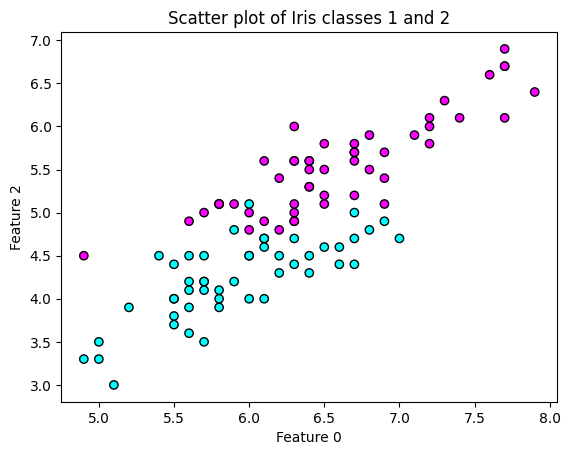

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# -----------------------------
# Load and prepare Iris data
# -----------------------------
iris = datasets.load_iris()
X = iris.data[:, [0, 2]]  # features 0 and 2
y = iris.target

# select only labels 1 and 2
mask = (y == 1) | (y == 2)
X = X[mask]
y = y[mask]

# Recode labels to 0 and 1 for sklearn (optional)
y_svm = y.copy()

# -----------------------------
# Part (a): Is data linearly separable?
# Quick visual check
plt.scatter(X[:,0], X[:,1], c=y_svm, cmap='cool', edgecolors='k')
plt.xlabel('Feature 0')
plt.ylabel('Feature 2')
plt.title('Scatter plot of Iris classes 1 and 2')
plt.show()


In [3]:

C_values = [0.001, 0.01, 0.1, 1, 5, 10, 50, 100, 500, 1000]
results = []

for C in C_values:
    clf = SVC(kernel='linear', C=C)
    clf.fit(X, y_svm)
    
    y_pred = clf.predict(X)
    error = 1 - accuracy_score(y_svm, y_pred)
    n_support_vectors = len(clf.support_)
    
    results.append((C, error, n_support_vectors))

# Print table
print("C\tTraining Error\t# Support Vectors")
for C, error, n_sv in results:
    print(f"{C}\t{error:.3f}\t\t{n_sv}")


C	Training Error	# Support Vectors
0.001	0.170		100
0.01	0.160		92
0.1	0.070		56
1	0.070		31
5	0.060		21
10	0.050		18
50	0.050		14
100	0.050		14
500	0.050		14
1000	0.050		14


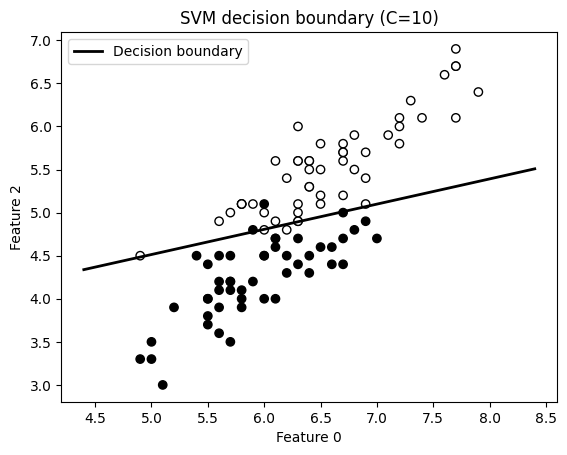

In [10]:
# -----------------------------
# Part (c): Plot decision boundary without mesh grid
# -----------------------------
best_idx = np.argmin([r[1] for r in results])
best_C = results[best_idx][0]
clf_best = SVC(kernel='linear', C=best_C)
clf_best.fit(X, y_svm)
# Get weights and bias from the trained SVM
w = clf_best.coef_[0]
b = clf_best.intercept_[0]

# Decision boundary: w0*x0 + w1*x1 + b = 0 => x1 = -(w0/w1)*x0 - b/w1
x0_plot = np.linspace(X[:,0].min()-0.5, X[:,0].max()+0.5, 200)
x1_plot = -(w[0]/w[1])*x0_plot - b/w[1]

plt.scatter(X[:,0], X[:,1], c=y_svm, cmap='cubehelix', edgecolors='k')
plt.plot(x0_plot, x1_plot, 'k-', linewidth=2, label='Decision boundary')
plt.xlabel('Feature 0')
plt.ylabel('Feature 2')
plt.title(f'SVM decision boundary (C={best_C})')
plt.legend()
plt.show()
